# Client Evaluation

This File reads all csv files of the ./client folder and concatenates them to a single dataframe, then used for further evaluation.

In [38]:
import pandas as pd
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
folder_path = './client'  

csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

df = pd.concat((pd.read_csv(file, delimiter=", ", engine="python") for file in csv_files), ignore_index=True)
df["Distance (m)"] = df["Distance (m)"].replace(30,5)

scenarios = df["Scenario"].unique()
scenarios.sort()

palette = sns.color_palette(n_colors=len(scenarios))
palette_dict = dict(zip(scenarios, palette))

In [40]:
df

,Transport Protocol,Scenario,Distance (m),Average RTT (ms),Jitter (ms)
0,TCP,Inner City,10,38.468485,8.541268
1,UDP,Inner City,10,59.157394,10.273248
2,UDP,Forest,10,316.862586,16.351774
3,TCP,Forest,5,30.377713,9.242297
4,UDP,Field,1,310.730079,12.276242
...,...,...,...,...,...
175,QUIC,Forest,1,338.827471,57.243946
176,UDP,Field,10,389.393333,208.395091
177,QUIC,Field,1,272.943871,11.044267
178,QUIC,Field,10,284.579669,168.461544


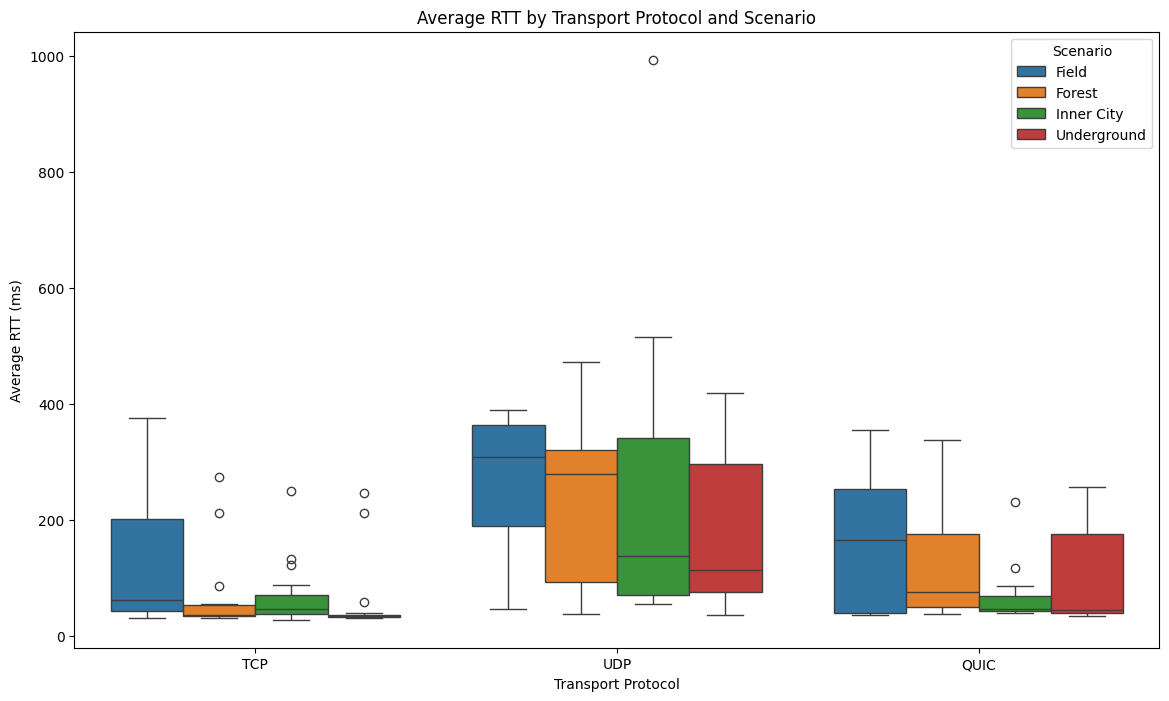

In [41]:
plt.figure(figsize=(14, 8))
sns.boxplot(x='Transport Protocol', y='Average RTT (ms)', hue='Scenario', data=df, palette=palette_dict, hue_order=scenarios)
plt.title('Average RTT by Transport Protocol and Scenario')
plt.ylabel('Average RTT (ms)')
plt.xlabel('Transport Protocol')
plt.legend(title='Scenario')
plt.show()

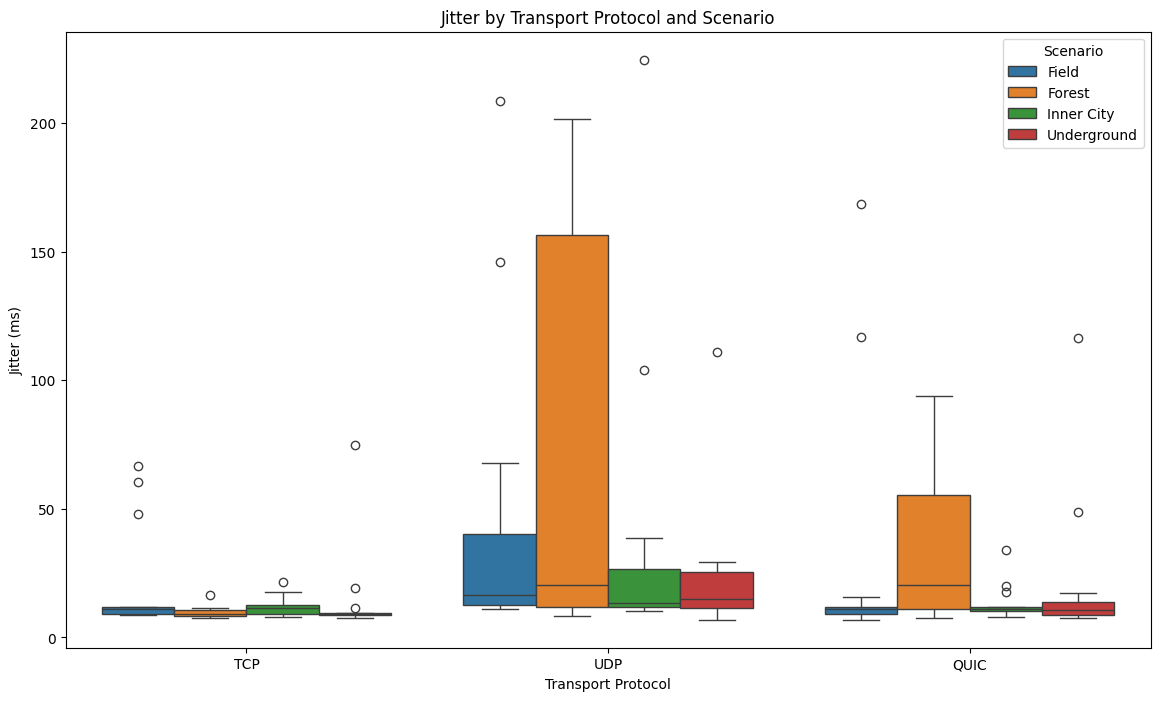

In [42]:
plt.figure(figsize=(14, 8))
sns.boxplot(x='Transport Protocol', y='Jitter (ms)', hue='Scenario', data=df, palette=palette_dict, hue_order=scenarios)
plt.title('Jitter by Transport Protocol and Scenario')
plt.ylabel('Jitter (ms)')
plt.xlabel('Transport Protocol')
plt.legend(title='Scenario')
plt.show()

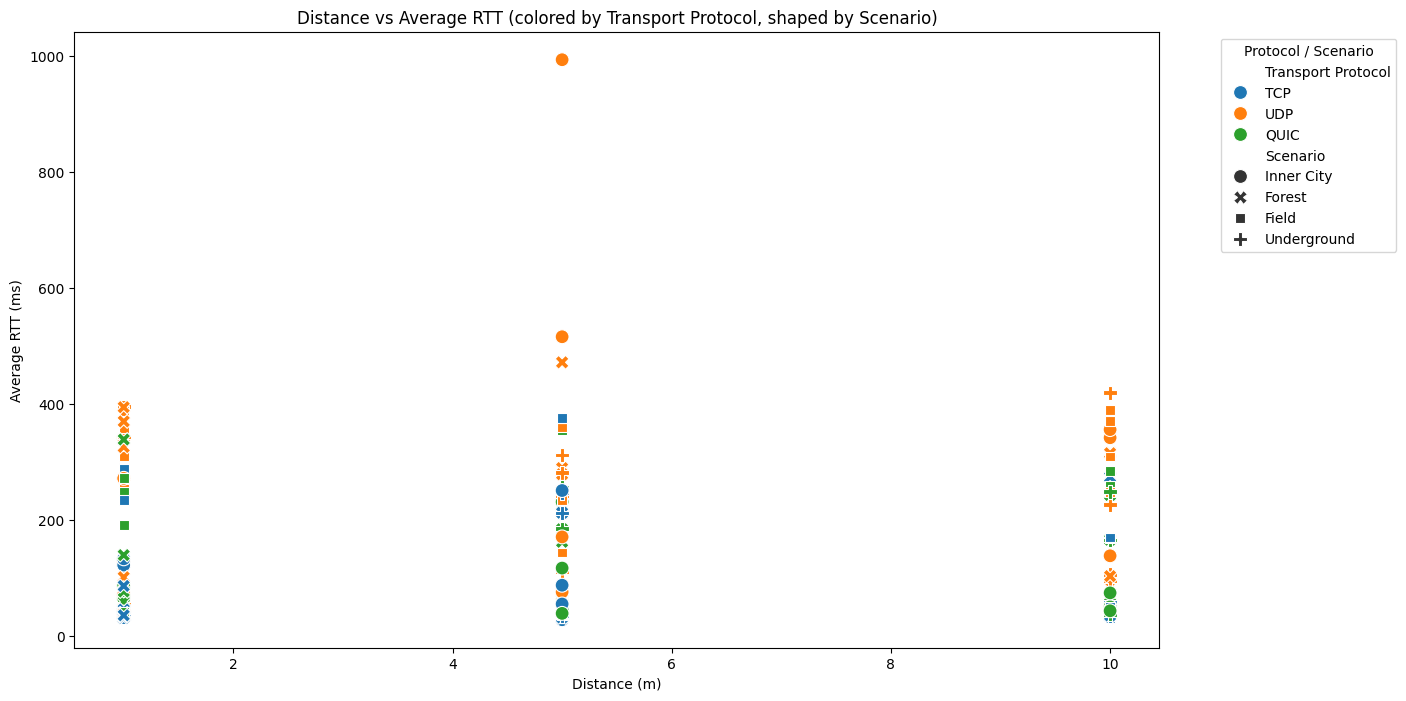

In [43]:
plt.figure(figsize=(14, 8))
sns.scatterplot(x='Distance (m)', y='Average RTT (ms)', hue='Transport Protocol', style='Scenario', data=df, s=100)
plt.title('Distance vs Average RTT (colored by Transport Protocol, shaped by Scenario)')
plt.xlabel('Distance (m)')
plt.ylabel('Average RTT (ms)')
plt.legend(title='Protocol / Scenario', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

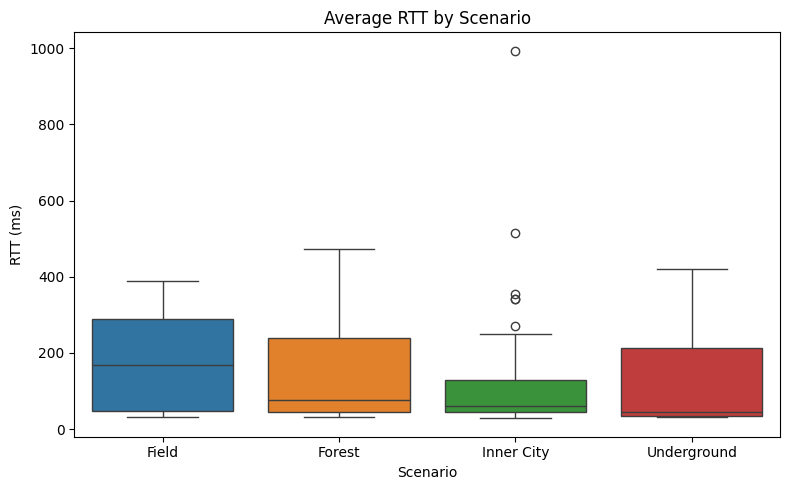

In [52]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Scenario', y='Average RTT (ms)', hue="Scenario", data=df, palette=palette_dict, order=scenarios)
plt.title('Average RTT by Scenario')
plt.ylabel('RTT (ms)')
plt.xlabel('Scenario')
plt.tight_layout()
plt.show()

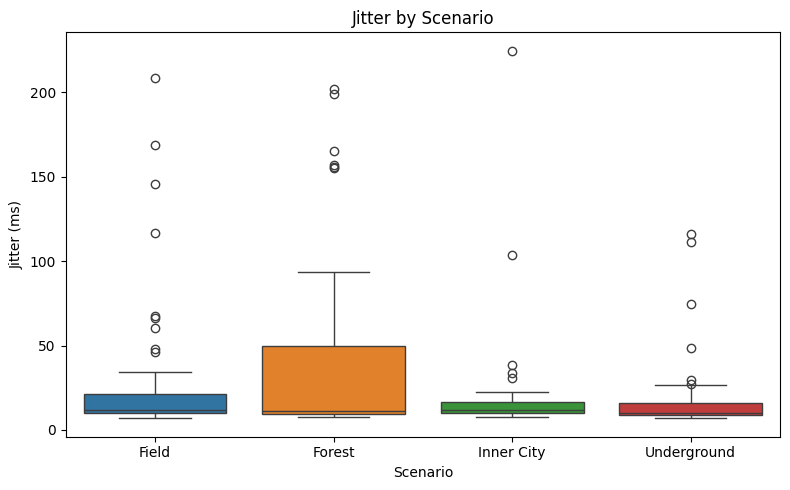

In [53]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Scenario', y='Jitter (ms)', hue='Scenario', data=df, palette=palette_dict, order=scenarios)
plt.title('Jitter by Scenario')
plt.ylabel('Jitter (ms)')
plt.xlabel('Scenario')
plt.tight_layout()
plt.show()

In [46]:
jitter_stats = df.groupby("Scenario")["Jitter (ms)"].describe()

In [47]:
jitter_stats.to_csv("jitter_scenario_stats.csv")
jitter_stats

,count,mean,std,min,25%,50%,75%,max
Scenario,,,,,,,,
Field,45.0,30.552624,44.800112,6.896699,10.279047,11.665953,21.199590,208.395091
Forest,45.0,40.576427,56.341343,7.429105,9.504099,11.492499,49.980442,201.616895
Inner City,45.0,20.658953,34.496459,7.869390,10.144808,11.731033,16.857606,224.581483
Underground,45.0,19.012306,23.869357,6.923351,8.880072,9.803440,16.157669,116.316138


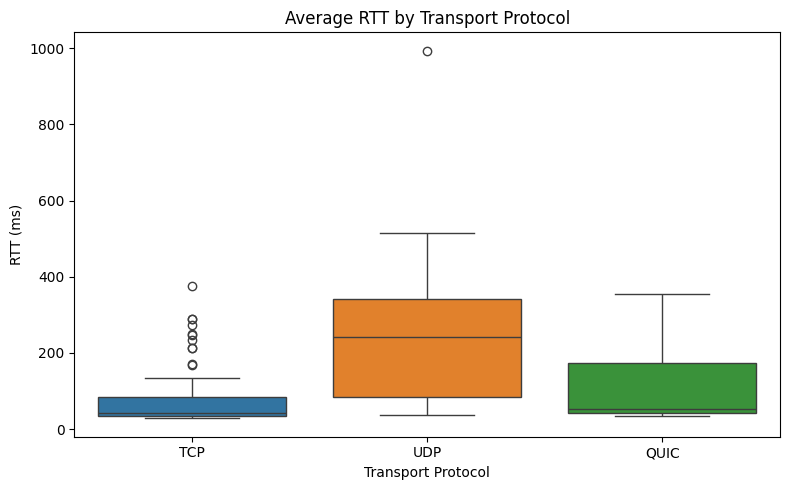

In [48]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Transport Protocol', y='Average RTT (ms)', hue="Transport Protocol", data=df)
plt.title('Average RTT by Transport Protocol')
plt.ylabel('RTT (ms)')
plt.xlabel('Transport Protocol')
plt.tight_layout()
plt.show()

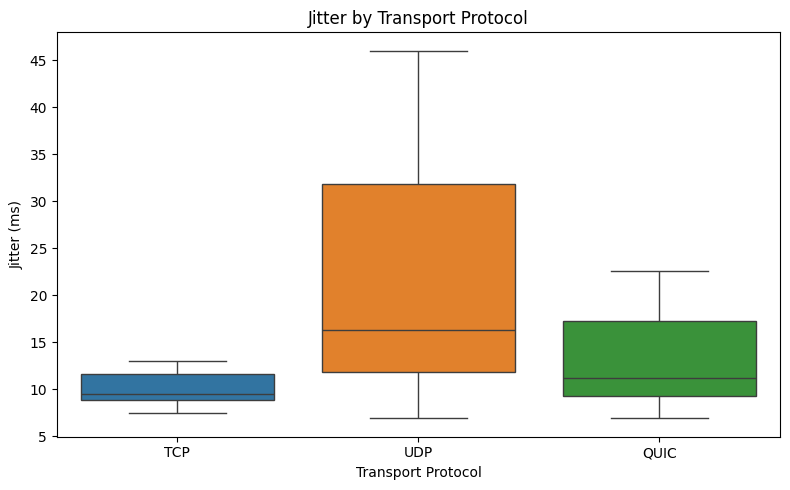

In [49]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Transport Protocol', y='Jitter (ms)', data=df, hue="Transport Protocol", showfliers=False)
plt.title('Jitter by Transport Protocol')
plt.ylabel('Jitter (ms)')
plt.xlabel('Transport Protocol')
plt.tight_layout()
plt.show()